# Plotly images

In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

## Add logo

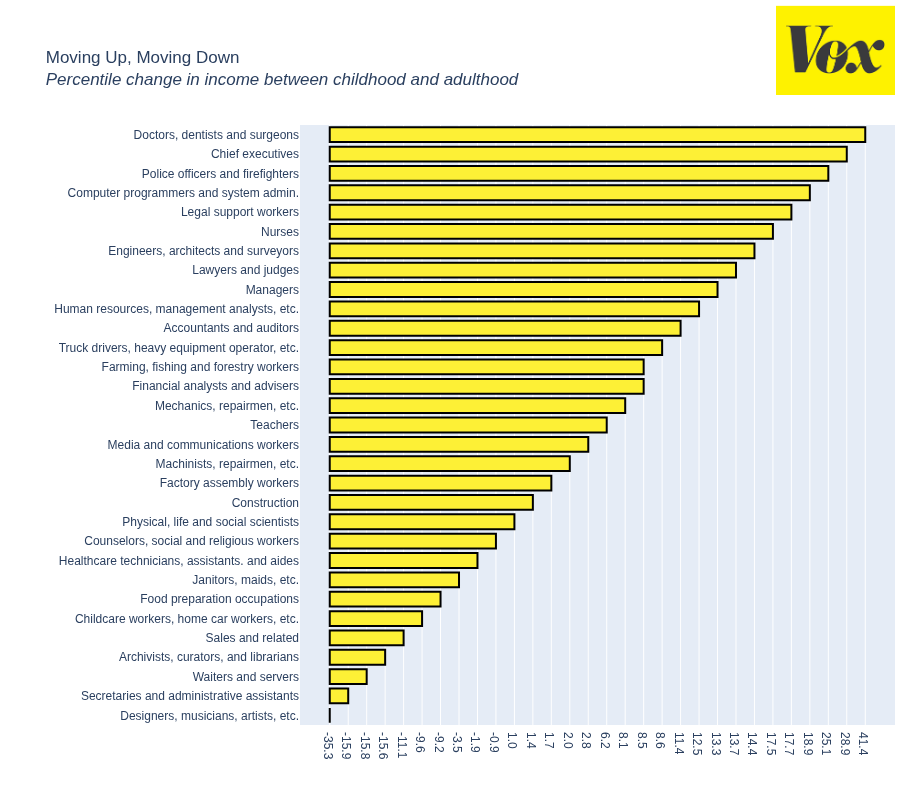

In [3]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=["-35.3", "-15.9", "-15.8", "-15.6", "-11.1",
           "-9.6", "-9.2", "-3.5", "-1.9", "-0.9",
           "1.0", "1.4", "1.7", "2.0", "2.8", "6.2",
           "8.1", "8.5", "8.5", "8.6", "11.4", "12.5",
           "13.3", "13.7", "14.4", "17.5", "17.7",
           "18.9", "25.1", "28.9", "41.4"],
        y=["Designers, musicians, artists, etc.",
           "Secretaries and administrative assistants",
           "Waiters and servers", "Archivists, curators, and librarians",
           "Sales and related", "Childcare workers, home car workers, etc.",
           "Food preparation occupations", "Janitors, maids, etc.",
           "Healthcare technicians, assistants. and aides",
           "Counselors, social and religious workers",
           "Physical, life and social scientists", "Construction",
           "Factory assembly workers", "Machinists, repairmen, etc.",
           "Media and communications workers", "Teachers",
           "Mechanics, repairmen, etc.", "Financial analysts and advisers",
           "Farming, fishing and forestry workers",
           "Truck drivers, heavy equipment operator, etc.", "Accountants and auditors",
           "Human resources, management analysts, etc.", "Managers",
           "Lawyers and judges", "Engineers, architects and surveyors",
           "Nurses", "Legal support workers",
           "Computer programmers and system admin.", "Police officers and firefighters",
           "Chief executives", "Doctors, dentists and surgeons"],
        marker=go.bar.Marker(
            color="rgb(253, 240, 54)",
            line=dict(color="rgb(0, 0, 0)",
                      width=2)
        ),
        orientation="h",
    )
)

# Add image
fig.add_layout_image(
    dict(
        source="https://raw.githubusercontent.com/cldougl/plot_images/add_r_img/vox.png",
        xref="paper", yref="paper",
        x=1, y=1.05,
        sizex=0.2, sizey=0.2,
        xanchor="right", yanchor="bottom"
    )
)

# update layout properties
fig.update_layout(
    autosize=False,
    height=800,
    width=700,
    bargap=0.15,
    bargroupgap=0.1,
    barmode="stack",
    hovermode="x",
    margin=dict(r=20, l=300, b=75, t=125),
    title=("Moving Up, Moving Down<br>" +
           "<i>Percentile change in income between childhood and adulthood</i>"),
)

fig.show()

## Label Spectroscopy Data by Adding Multiple Images

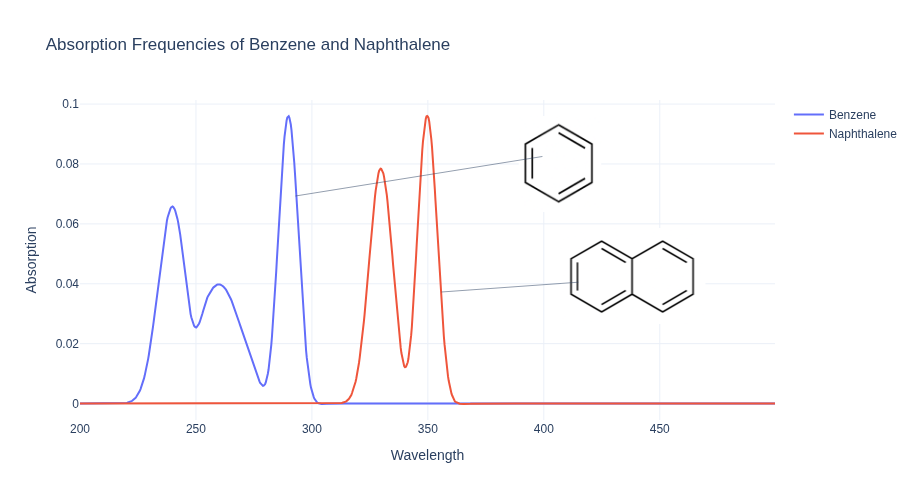

In [5]:
np.random.seed(1)
from scipy.signal import savgol_filter

# Simulate spectroscopy data
def simulated_absorption(mu, sigma, intensity):
    data = [np.random.normal(mu[i], sigma[i], intensity[i]) for i in range(len(mu))]
    hists = [np.histogram(d, 1000, range=(200, 500), density=True) for d in data]
    ys = [y for y, x in hists]
    s = savgol_filter(np.max(ys, axis=0), 41, 3)
    return hists[0][1], s

mus = [[290, 240, 260], [330, 350]]
sigmas = [[4, 6, 10], [5, 4]]
intensities = [[100000, 300000, 700000], [40000, 20000]]
simulated_absorptions = [simulated_absorption(m, s, i) for m, s, i in
                         zip(mus, sigmas, intensities)]

# Create figure
fig = go.Figure()

# Create traces from data
names = ["Benzene", "Naphthalene"]
for (x, y), n in zip(simulated_absorptions, names):
    fig.add_trace(go.Scatter(x=x, y=y, name=n))

# Add images
fig.add_layout_image(
    dict(
        source="https://raw.githubusercontent.com/michaelbabyn/plot_data/master/benzene.png",
        x=0.75,
        y=0.65,
    ))
fig.add_layout_image(dict(
        source="https://raw.githubusercontent.com/michaelbabyn/plot_data/master/naphthalene.png",
        x=0.9,
        y=0.3,
        )
)
fig.update_layout_images(dict(
        xref="paper",
        yref="paper",
        sizex=0.3,
        sizey=0.3,
        xanchor="right",
        yanchor="bottom"
))

# Add annotations
fig.update_layout(
    annotations=[
        dict(
            x=93.0 / 300,
            y=0.07 / 0.1,
            xref="paper",
            yref="paper",
            showarrow=True,
            arrowhead=0,
            opacity=0.5,
            ax=250,
            ay=-40,
        ),
        dict(
            x=156.0 / 300,
            y=0.04 / 0.1,
            xref="paper",
            yref="paper",
            showarrow=True,
            arrowhead=0,
            opacity=0.5,
            ax=140,
            ay=-10,
        )
    ]
)

# Configure axes
fig.update_xaxes(title_text="Wavelength")
fig.update_yaxes(title_text="Absorption", hoverformat=".3f")

# Configure other layout properties
fig.update_layout(
    title_text="Absorption Frequencies of Benzene and Naphthalene",
    height=500,
    width=900,
    template="plotly_white"
)

fig.show()

## Zoom on Static Images

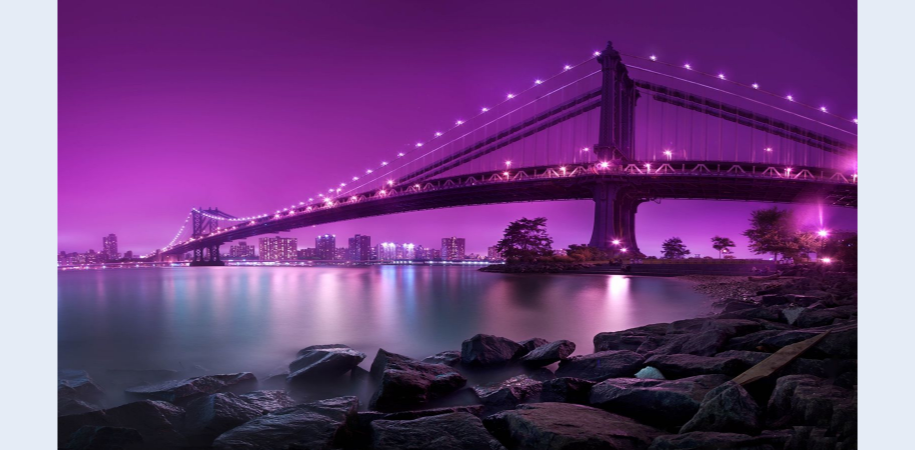

In [6]:
# Create figure
fig = go.Figure()

# Constants
img_width = 1600
img_height = 900
scale_factor = 0.5

# Add invisible scatter trace.
# This trace is added to help the autoresize logic work.
fig.add_trace(
    go.Scatter(
        x=[0, img_width * scale_factor],
        y=[0, img_height * scale_factor],
        mode="markers",
        marker_opacity=0
    )
)

# Configure axes
fig.update_xaxes(
    visible=False,
    range=[0, img_width * scale_factor]
)

fig.update_yaxes(
    visible=False,
    range=[0, img_height * scale_factor],
    # the scaleanchor attribute ensures that the aspect ratio stays constant
    scaleanchor="x"
)

# Add image
fig.add_layout_image(
    dict(
        x=0,
        sizex=img_width * scale_factor,
        y=img_height * scale_factor,
        sizey=img_height * scale_factor,
        xref="x",
        yref="y",
        opacity=1.0,
        layer="below",
        sizing="stretch",
        source="https://raw.githubusercontent.com/michaelbabyn/plot_data/master/bridge.jpg")
)

# Configure other layout
fig.update_layout(
    width=img_width * scale_factor,
    height=img_height * scale_factor,
    margin={"l": 0, "r": 0, "t": 0, "b": 0},
)

# Disable the autosize on double click because it adds unwanted margins around the image
# More detail: https://plotly.com/python/configuration-options/
fig.show(config={'doubleClick': 'reset'})

# References
## Plotly Documentation
* Images in Python: https://plotly.com/python/images/